## Import libraries 

In [48]:
# In case xlsxwriter do not install common way
# import sys
# import subprocess

# subprocess.check_call([
#     sys.executable,
#     "-m",
#     "pip",
#     "install",
#     "XlsxWriter"
# ])
###############################################

# uploaad nessery packages


import os 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
import seaborn as sns
import xlsxwriter


from scikit_posthocs import posthoc_dunn as dunn
from scipy.stats import mannwhitneyu, false_discovery_control, kruskal

data_path = os.path.dirname(os.getcwd()).replace('\\', '/') + '/data/'
plot_path = os.path.dirname(os.getcwd()).replace('\\', '/') + '/Plots/'


sns.set_theme(style="whitegrid")

## Additional functions

### Functions that highlights significant values with red color

In [49]:
def sinificant_bold_red(val):
    """
    Applies 'font-weight: bold' and 'color: red' if P-value below 0.05.
    If value above 0.05 color is lightgrey
    """
    if isinstance(val, (int, float)):
        color = "#AA0000" if val <= 0.055 else "#AFAFAF"
        font_weight = 'bold' if val <= 0.055 else 'normal' 
        return f'color: {color}; font-weight: {font_weight}'
        
    return ''


def sinificant_bold_red_for_excel(val):
    """
    Applies 'font-weight: bold' and 'color: red' if P-value below 0.05.
    If value above 0.05 color is black
    """
    if isinstance(val, (int, float)):
        color = "#AA0000" if val <= 0.055 else "#000000"
        font_weight = 'bold' if val <= 0.055 else 'normal' 
        return f'color: {color}; font-weight: {font_weight}'
        
    return ''


### Function for boxplot recoloring

In [50]:
# This function recolores boxplots in pairwise manner (look at cell 17) 
def recolor_boxes_by_position(current_ax, group_order, group_colors):
    current_ax.figure.canvas.draw()

    renderer = current_ax.figure.canvas.get_renderer()

    # Set patches for boxes
    box_patches = [
        patch
        for patch in current_ax.patches
        if isinstance(patch, PathPatch)
    ]

    # Group boxes according to group order
    boxes_by_group = {
        group_index: []
        for group_index in range(len(group_order))
    }

    # Find the horizontal position of each box
    for patch in box_patches:
        bbox = patch.get_window_extent(renderer=renderer)

        center_display = (
            (bbox.x0 + bbox.x1) / 2,
            (bbox.y0 + bbox.y1) / 2
        )

        center_data = current_ax.transData.inverted().transform(
            center_display
        )

        x_position = center_data[0]

        # Assign box to the nearest animal-group position
        group_index = min(
            range(len(group_order)),
            key=lambda i: abs(i - x_position)
        )

        boxes_by_group[group_index].append(
            (x_position, patch)
        )

    # Sort boxes left-to-right and apply colors
    for group_index, group in enumerate(group_order):

        group_boxes = sorted(
            boxes_by_group[group_index],
            key=lambda item: item[0]
        )

        expected_number = len(group_colors[group])

        if len(group_boxes) != expected_number:
            print(
                f"Warning: {group} has {len(group_boxes)} boxes, "
                f"but {expected_number} colors were provided."
            )

        for patch_number, (_, patch) in enumerate(group_boxes):
            if patch_number >= expected_number:
                break

            patch.set_facecolor(
                group_colors[group][patch_number]
            )
            patch.set_edgecolor("black")
            patch.set_alpha(0.7)

### Creates recolored boxplot with stripplot

In [51]:
# Creates boxplot wih stripplot
def box_strip_plot(data, x, y, hue, ax, xtick_labels, xtick_number=[0, 1, 2, 3],
                   palette='Paired', order=None, hue_order=None, dodge=True):
    
    
    sns.boxplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax,  
                legend=False, showfliers=False, boxprops={'alpha': 0.85,
                                                          'linewidth': 1.5},
                medianprops={'linewidth': 2}, order=order, hue_order=hue_order)
    
    
    recolor_boxes_by_position(
                current_ax,
                group_order,
                pair_colors)
    
    
        
    sns.stripplot(data=data, x=x, y=y,  ax=ax,
                  legend=False, hue=hue, palette=palette, dodge=dodge,
                  edgecolor='black', linewidth=0.5, alpha=0.85, order=order)  
    
    
    ax.set_xticks(xtick_number, labels=xtick_labels)
    ax.set_xlabel('')  

### Saves Kruskal/Dunn data to xlsx

In [52]:

# Function that saves output to excel file (see the cell 24) 
def excel_saver(data, sheet_name, start_row, table_start_row, 
                start_col, group_name, kruscal_p, var_name, 
                writer, float_format='%.3f'):
    
    # Creates Excel book
    workbook = writer.book
    
    # Sets formating for Dunn table
    heading_format = workbook.add_format({"bold": True, "font_size": 12})
    label_format = workbook.add_format({"bold": True})
    pvalue_format = workbook.add_format({"num_format": "0.000"})
    
    # Point where begins table writing (need for aditional info upwards from the table) 
    table_start_row = start_row + 3
    
    # Saves data to excel                        
    data.to_excel(
        writer,
        sheet_name=sheet_name,
        float_format=float_format,
        startrow=table_start_row,
        startcol=start_col,
        index=True)
    
    # Sets worksheet name
    worksheet = writer.sheets[sheet_name]
    
    # Write the text above the table
    worksheet.write(
        start_row,
        start_col,
        f"Group is {group_name}",
        heading_format)

    worksheet.write(
        start_row + 1,
        start_col,
        f"Kruskal p-value for {var_name}: {kruscal_p:.3f}",
        label_format)

    worksheet.write(
        start_row + 2,
        start_col,
        "Dunn's post-hoc values with FDR-BH:",
        heading_format)

### Performs KW-test with Dunn posthoc

In [53]:
# Function that calculates kw data with Dunn's post-hoc
def kw_dunn_calc(data, timepoint, animal_gr, sheet_name):
    
    # sets start col in excel file from where writing begins 
    start_col = 0
    
    # Subsets data by month
    for month in data[timepoint].unique():
        
        mask_1 = data[timepoint] == month
        temp_data = data[mask_1]

        # Subsets data by animal group
        wistar, balb, black, hamster = [temp_data[temp_data[animal_gr] == i] \
            for i in temp_data[animal_gr].unique()]
               
        # sets start row in excel file from where writing begins 
        start_row = 0
        
        # Performs Kruscal and Dunn's posthoc
        for col in temp_data.columns[2:]:           
            
            kruskal_p =kruskal(wistar[col], balb[col], 
                            black[col], hamster[col]).pvalue
        
            
            dunn_results = dunn(a=temp_data, 
                                group_col='animal_group', 
                                val_col=col,
                                p_adjust='fdr_bh')
            
            # Creates styled dataframes
            styled_dunn_excel = \
                dunn_results.style.map(sinificant_bold_red_for_excel).format('{:.3f}')           
            
################################ Saves to excel ################################# 
            table_start_row = start_row + 3

            excel_saver(data=styled_dunn_excel, sheet_name=sheet_name, 
                        writer=writer, start_row=start_row, 
                        table_start_row=table_start_row, start_col=start_col, 
                        group_name=month, var_name=col, kruscal_p=kruskal_p)                                      
################################################################################

            # Number of rows plus header plus one blank row
            start_row += len(dunn_results) + 6
        start_col += len(dunn_results) + 2

## Investigation of parasite burden 

In [54]:
# Upload fluke data
fluke_data = pd.read_excel(data_path + 'data_four_species.xlsx', 
                           sheet_name='fluke_data').drop('ID', axis=1)
display(fluke_data)

,animal_group,timepoint,liver_flukes,flukes_per_mass,eggs_in_feces,eggs_per_flukes
0,wistar,1_month,0,0.0,0,0.0
1,wistar,1_month,0,0.0,0,0.0
2,wistar,1_month,0,0.0,0,0.0
3,wistar,1_month,0,0.0,0,0.0
4,wistar,1_month,0,0.0,0,0.0
5,balb,1_month,0,0.0,0,0.0
6,balb,1_month,0,0.0,0,0.0
7,balb,1_month,0,0.0,0,0.0
8,balb,1_month,0,0.0,0,0.0
9,balb,1_month,1,0.8,0,0.0


### Display data with boxplot

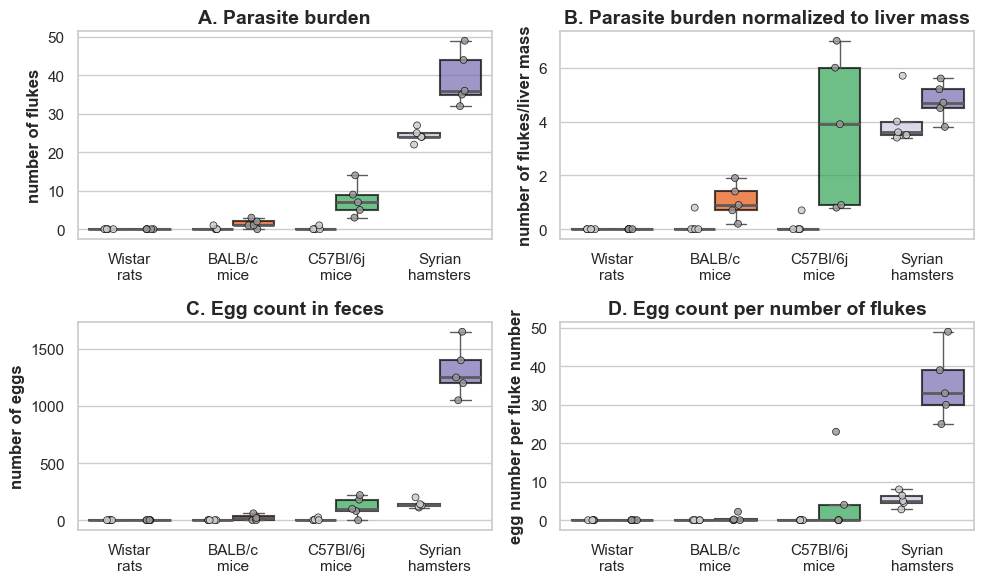

In [55]:
# Sets titles and x, y axis names for boxplots 
titles = ['A. Parasite burden', 'B. Parasite burden normalized to liver mass',
          'C. Egg count in feces', 'D. Egg count per number of flukes']

mesure_lst =['number of flukes', 'number of flukes/liver mass', 
             'number of eggs', 'egg number per fluke number']

x_axis_names = ['Wistar\nrats', 'BALB/c\nmice', 'C57Bl/6j\nmice', 'Syrian\nhamsters']


# Set colors for boxes
group_order = ["wistar", "balb", "black", "hamster"]
time_order = ["1_month", "3_month"]

pair_colors = {
    "wistar":  ["#9ecae1", "#3182bd"],
    "balb":    ["#fdae6b", "#e6550d"],
    "black":   ["#a1d99b", "#31a354"],
    "hamster": ["#cbc9e2", "#756bb1"],
}

timepoint_palette = {
    "1_month": "#cccccc",
    "3_month": "#999999"
}



# Creates figure
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# Creates boxplots with stripplot
for index, column in enumerate(fluke_data.columns[2:]):

    # Sets current ax for box coloring
    current_ax = ax[index // 2, index % 2]
    
    if index < 2:
        box_strip_plot(data=fluke_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[0, index],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)
        
        ax[0, index].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[0, index].set_xlabel('')
        ax[0, index].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')

    else: 
        box_strip_plot(data=fluke_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[1, index-2],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)


        ax[1, index-2].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[1, index-2].set_xlabel('')
        ax[1, index-2].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')

fig.tight_layout()


# Saves plot to specific directory
plt.savefig(plot_path+"Figure_2_eggs_and_worms/parasite_plot", dpi=300, bbox_inches="tight")

### Compare animal withing one group (1st month vs 3rd month)

In [56]:
# Subset data for each animal
wistar, balb, black, hamster = [fluke_data[fluke_data['animal_group'] == i] \
        for i in fluke_data['animal_group'].unique()]

# Create empty list for p-values 
p_values=[]

# Cycle that calculate MWU-test for each parameter
for animal in [wistar, balb, black, hamster]:
    
    x=animal[animal['timepoint'] == '1_month']
    y=animal[animal['timepoint'] == '3_month']

    for col in animal.columns[2:]:
        mwu_result = mannwhitneyu(x[col], y[col]).pvalue
        p_values.append(mwu_result)
             
             
# Apply correction for multiple comparations 
p_values = false_discovery_control(p_values, method='bh')
  

# Display the result
for animal in [wistar, balb, black, hamster]: 
    print(f'1 vs 3 months for animal: \033[1m{animal['animal_group'].unique()[0]}\033[0m')


    # Display results of corrected MWU-test
    for index, col in enumerate(animal.columns[2:]):
        print(f'For parameter:\033[1m{col}\033[0m Mann-Whitney result: \033[1m{p_values[index]:.3f}\033[0m')   
        
    # Removes first 4 values from p-value
    p_values = p_values[4:]
    print()

1 vs 3 months for animal: wistar
For parameter:liver_flukes Mann-Whitney result: 1.000
For parameter:flukes_per_mass Mann-Whitney result: 1.000
For parameter:eggs_in_feces Mann-Whitney result: 1.000
For parameter:eggs_per_flukes Mann-Whitney result: 1.000

1 vs 3 months for animal: balb
For parameter:liver_flukes Mann-Whitney result: 0.128
For parameter:flukes_per_mass Mann-Whitney result: 0.083
For parameter:eggs_in_feces Mann-Whitney result: 0.128
For parameter:eggs_per_flukes Mann-Whitney result: 0.261

1 vs 3 months for animal: black
For parameter:liver_flukes Mann-Whitney result: 0.038
For parameter:flukes_per_mass Mann-Whitney result: 0.038
For parameter:eggs_in_feces Mann-Whitney result: 0.128
For parameter:eggs_per_flukes Mann-Whitney result: 0.261

1 vs 3 months for animal: hamster
For parameter:liver_flukes Mann-Whitney result: 0.038
For parameter:flukes_per_mass Mann-Whitney result: 0.296
For parameter:eggs_in_feces Mann-Whitney result: 0.038
For parameter:eggs_per_flukes Ma

## Investigation of liver data

In [57]:
liver_data = pd.read_excel(data_path + 'data_four_species.xlsx', 
                           sheet_name='liver_data').drop('ID', axis=1)
display(liver_data)

,animal_group,timepoint,hyperplasia,inflammation,PF,ChF,AST,ALT
0,wistar,control,0.10000,0.10000,0.10000,0.00001,13,12
1,wistar,control,0.40000,0.00001,0.30000,0.20000,18,20
2,wistar,control,0.50000,0.20000,0.20000,0.20000,21,22
3,wistar,control,0.70000,0.30000,0.10000,0.40000,21,24
4,wistar,control,0.90000,0.50000,0.30000,0.60000,23,26
5,wistar,1_month,0.00001,0.40000,1.80000,0.00001,20,22
6,wistar,1_month,0.10000,0.50000,2.00000,0.10000,21,23
7,wistar,1_month,0.20000,0.50000,2.50000,0.20000,22,23
8,wistar,1_month,0.30000,0.70000,3.00000,0.40000,22,24
9,wistar,1_month,0.40000,0.90000,3.20000,0.20000,23,30


### Display data with boxlot

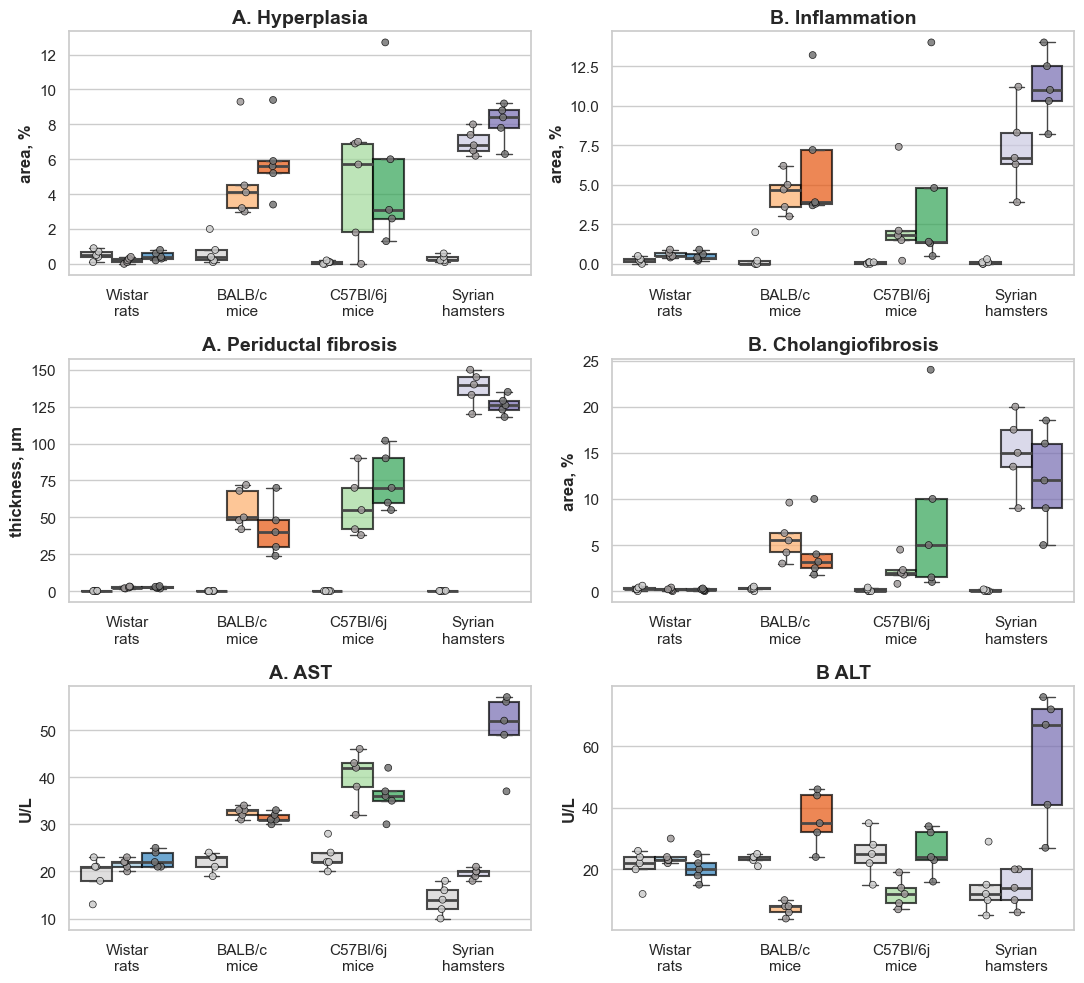

In [ ]:
# Sets titles and x, y axis names for boxplots 
titles = ['A. Hyperplasia', 'B. Inflammation', 'A. Periductal fibrosis',
          'B. Cholangiofibrosis', 'A. AST', 'B ALT']

mesure_lst =['area, %', 'area, %', 'thickness, μm', 'area, %', 'U/L', 'U/L']

x_axis_names = ['Wistar\nrats', 'BALB/c\nmice', 'C57Bl/6j\nmice', 'Syrian\nhamsters']


# Set colors for boxes
group_order = ["wistar", "balb", "black", "hamster"]
time_order = ["control", "1_month", "3_month"]

pair_colors = {
    "wistar":  ["#d2d0d0", "#9ecae1", "#3182bd"],
    "balb":    ["#d2d0d0", "#fdae6b", "#e6550d"],
    "black":   ["#d2d0d0", "#a1d99b", "#31a354"],
    "hamster": ["#d2d0d0", "#cbc9e2", "#756bb1"],
}

timepoint_palette = {
    "control": "#cccccc",
    "1_month": "#9f9a9a",
    "3_month": "#767676"
}


# Creates figure
fig, ax = plt.subplots(3, 2, figsize=(11, 10))

# Creates boxplots with stripplot
for index, column in enumerate(liver_data.columns[2:]):

    # Sets current ax for box coloring
    current_ax = ax[index // 2, index % 2]  
    
    if index < 2:
        box_strip_plot(data=liver_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[0, index],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)
        
        ax[0, index].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[0, index].set_xlabel('')
        ax[0, index].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')
             
    elif index >= 2 and index < 4:
            box_strip_plot(data=liver_data, x='animal_group', 
                        y=column, hue='timepoint', ax=ax[1, index-2],                   
                        palette=timepoint_palette, order=group_order, 
                        hue_order=time_order, xtick_labels=x_axis_names)
            
            ax[1, index-2].set_title(titles[index], fontsize=14, fontweight='bold')
            ax[1, index-2].set_xlabel('')
            ax[1, index-2].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')

    else: 
        box_strip_plot(data=liver_data, x='animal_group', 
                    y=column, hue='timepoint', ax=ax[2, index-4],                   
                    palette=timepoint_palette, order=group_order, 
                    hue_order=time_order, xtick_labels=x_axis_names)
        
        ax[2, index-4].set_title(titles[index], fontsize=14, fontweight='bold')
        ax[2, index-4].set_xlabel('')
        ax[2, index-4].set_ylabel(mesure_lst[index], fontsize=12, fontweight='bold')

fig.tight_layout()

# Saves plot to specific directory
plt.savefig(plot_path+"Figure_4_ast_alt_fibrosis/hystology_plot", dpi=300, bbox_inches="tight")

In [59]:
# Sets output file
output_file = path + "KW_dunn_between_month.xlsx"

# Sets sheet name for excel saver
sheet_name='KW_dunn_between_month'

# Writes output with xlsxwriter
with pd.ExcelWriter(
    output_file,
    engine="xlsxwriter"
) as writer:


    # Sets start col in excel file
    start_col = 0
    
    # Subset data for each animal
    wistar, balb, black, hamster = [liver_data[liver_data['animal_group'] == i] \
            for i in liver_data['animal_group'].unique()]

    # Divides data into three groups based on duration of infection
    for animal in [wistar, balb, black, hamster]:
        x = animal[animal['timepoint'] == 'control']
        y =  animal[animal['timepoint'] == '1_month']
        z = animal[animal['timepoint'] == '3_month']

        
        # Sets start row in excel file
        start_row = 0
        
        # Performs KW-test with Dunn's post-hoc
        for col in animal.columns[2:]:
            
            p_value = kruskal(x[col], y[col], z[col]).pvalue
            
            dunn_results = dunn(a=animal, 
                                group_col='timepoint', 
                                val_col=col,
                                p_adjust='fdr_bh')
            
            # Sets format for Dunn's output                   
            styled_dunn_excel = \
                dunn_results.style.map(sinificant_bold_red_for_excel).format('{:.3f}')
                
                
            # Sets table start row 
            table_start_row = start_row + 3
            
            
            # Saves KW and Dunn's output to excel file
            excel_saver(data=styled_dunn_excel, sheet_name=sheet_name, 
                        writer=writer, start_row=start_row, 
                        table_start_row=table_start_row, start_col=start_col, 
                        group_name=animal['animal_group'].unique()[0], 
                        var_name=col, kruscal_p=p_value)

################################################################################
            # Number of rows plus header plus one blank row
            start_row += len(dunn_results) + 6
        start_col += len(dunn_results) + 2

## KW-test & Dunn-test for liver_data and fluke_data (saved to data/all_parasite_result.xlsx)

In [60]:
# Creates dictionary with datasets
datasets = {
    "Liver_results": liver_data,
    "Fluke_results": fluke_data
}

# Creates output file
output_file = path + "KW_dunn_results_withing_month.xlsx"

# Performs KW-test with Dunn's post-hoc and saves to excel file
with pd.ExcelWriter(
    output_file,
    engine="xlsxwriter"
) as writer:

    for sheet_name, data in datasets.items():

        kw_dunn_calc(data=data, sheet_name=sheet_name,
            timepoint='timepoint', animal_gr='animal_group')